<a href="https://colab.research.google.com/github/KarabiMandal185/Application-of-Data-Mining/blob/main/LAB_EXAM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

In [7]:
df = pd.read_csv("/content/iris.csv")

In [8]:
print("First 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nNull values:")
print(df.isnull().sum())

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Null values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [9]:
label_encoder = LabelEncoder()
df['species_encoded'] = label_encoder.fit_transform(df['species'])

In [10]:
X = df.drop(['species', 'species_encoded'], axis=1)
y_true = df['species_encoded']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

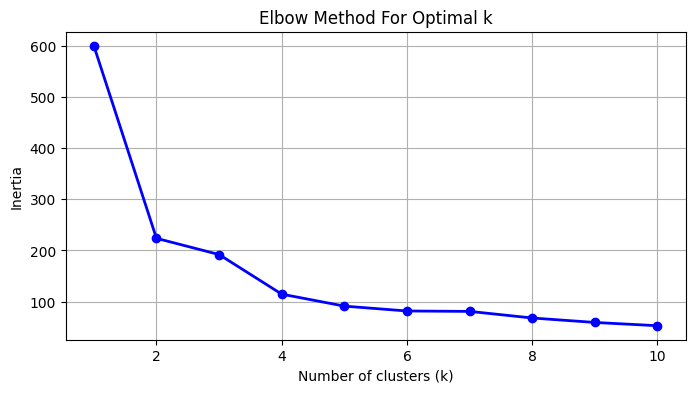

In [13]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.grid(True)
plt.show()

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids = pca.transform(kmeans.cluster_centers_)


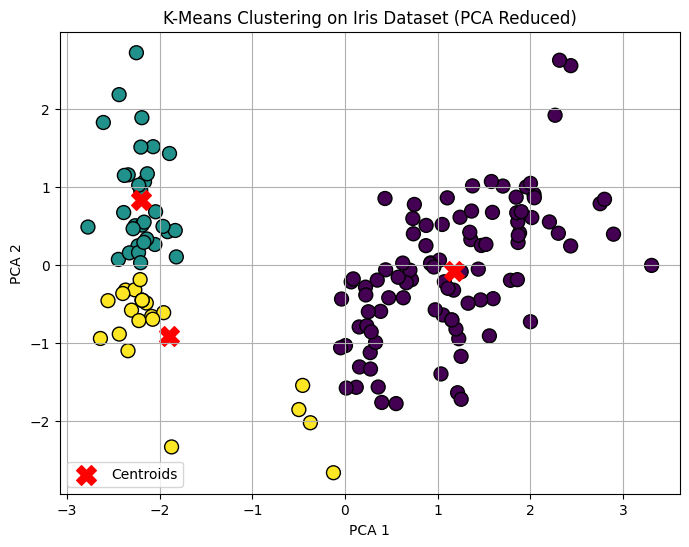

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=100, edgecolor='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering on Iris Dataset (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print("\nConfusion Matrix (KMeans clusters vs True Labels):")
conf_mat = confusion_matrix(y_true, y_kmeans)
print(conf_mat)


Confusion Matrix (KMeans clusters vs True Labels):
[[ 0 32 18]
 [46  0  4]
 [50  0  0]]


In [18]:
from scipy.stats import mode
labels_matched = np.zeros_like(y_kmeans)
for i in range(3):
    mask = (y_kmeans == i)
    labels_matched[mask] = mode(y_true[mask], keepdims=True).mode[0]

acc = accuracy_score(y_true, labels_matched)
print(f"\nAccuracy (after matching clusters to true labels): {acc:.2f}")



Accuracy (after matching clusters to true labels): 0.67


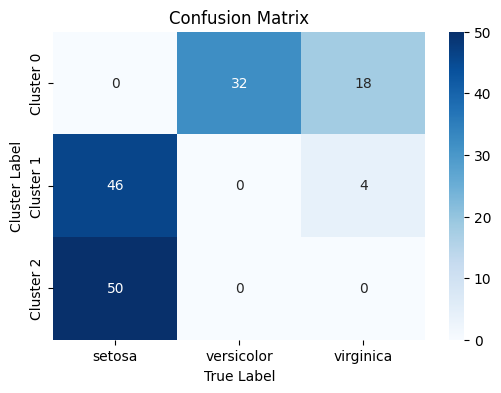

In [19]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=[f"Cluster {i}" for i in range(3)])
plt.title("Confusion Matrix")
plt.xlabel("True Label")
plt.ylabel("Cluster Label")
plt.show()